# Практика 16. Кореляційний аналіз: діаграма розсіювання, коефіцієнти Пірсона і Спірмена, кореляційна матриця

**Варіант 1: Київ**

Мета: дослідити зв'язок між температурою, опалювальними днями та витратами на опалення за допомогою діаграми розсіювання, коефіцієнтів Пірсона і Спірмена та кореляційних матриць.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

variant = 1
city = 'Київ'
monthly_temp = [-4, -3, 2, 9, 15, 19, 21, 20, 14, 8, 2, -2]
months = ['Січ', 'Лют', 'Бер', 'Кві', 'Тра', 'Чер', 'Лип', 'Сер', 'Вер', 'Жов', 'Лис', 'Гру']
alpha = 0.05

np.random.seed(variant)
rows = []
for month, temp in zip(months, monthly_temp):
    heating_days = np.clip(18 - temp + np.random.normal(0, 1.5), 0, 30)
    heating_days = round(heating_days)
    cost = 0.15 * heating_days + np.random.normal(0, 1.0)
    cost = round(max(cost, 0), 1)
    rows.append({
        'місто': city,
        'місяць': month,
        'температура': temp,
        'опалювальні_дні': heating_days,
        'витрати_на_опалення': cost,
    })

climate = pd.DataFrame(rows)
print(f'Варіант {variant}: {city}')
print(climate)

Варіант 1: Київ
   місто місяць  температура  опалювальні_дні  витрати_на_опалення
0   Київ    Січ           -4               24                  3.0
1   Київ    Лют           -3               20                  1.9
2   Київ    Бер            2               17                  0.2
3   Київ    Кві            9               12                  1.0
4   Київ    Тра           15                3                  0.2
5   Київ    Чер           19                1                  0.0
6   Київ    Лип           21                0                  0.0
7   Київ    Сер           20                0                  0.0
8   Київ    Вер           14                4                  0.0
9   Київ    Жов            8               10                  2.1
10  Київ    Лис            2               14                  3.2
11  Київ    Гру           -2               21                  3.7


## Побудова кліматичного набору

Варіант 1 — Київ. Використано 12 середньомісячних температур із таблиці практики, `seed=1`, а похідні змінні згенеровано точно за заданою формулою.

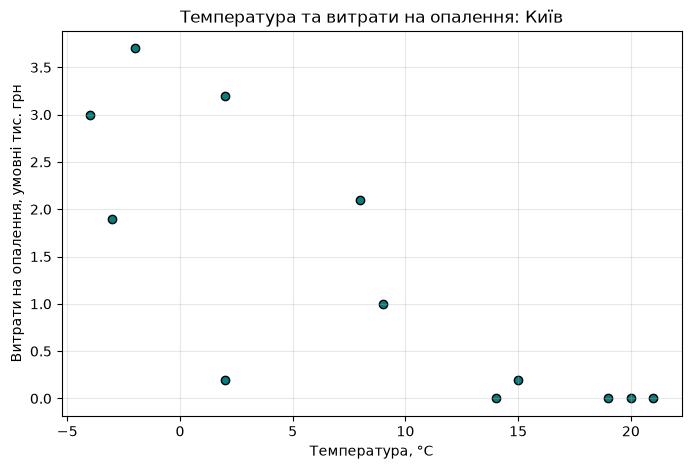

Хмара точок має очікуваний негативний напрямок: зі зростанням температури потреба в опаленні зменшується.


In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(climate['температура'], climate['витрати_на_опалення'], color='teal', edgecolor='black')
ax.set_xlabel('Температура, °C')
ax.set_ylabel('Витрати на опалення, умовні тис. грн')
ax.set_title('Температура та витрати на опалення: Київ')
ax.grid(alpha=0.3)
plt.show()

print('Хмара точок має очікуваний негативний напрямок: зі зростанням температури потреба в опаленні зменшується.')

## Завдання 1. Діаграма розсіювання

На осі X — середньомісячна температура в °C, на осі Y — витрати на опалення в умовних тис. грн. Очікуємо негативний, приблизно лінійний зв'язок: холодніші місяці потребують більше опалення.

In [3]:
pearson_result = pearsonr(climate['температура'], climate['витрати_на_опалення'])
spearman_result = spearmanr(climate['температура'], climate['витрати_на_опалення'])
pearson_ci = pearson_result.confidence_interval(confidence_level=0.95)

print(f"Пірсон: r = {pearson_result.statistic:.4f}, p-value = {pearson_result.pvalue:.6f}")
print(f"Спірмен: rho = {spearman_result.statistic:.4f}, p-value = {spearman_result.pvalue:.6f}")
print(f'95%-й ДІ для r: ({pearson_ci.low:.4f}, {pearson_ci.high:.4f})')
print('Пірсон: відхиляємо H₀.' if pearson_result.pvalue < alpha else 'Пірсон: не відхиляємо H₀.')
print('Спірмен: відхиляємо H₀.' if spearman_result.pvalue < alpha else 'Спірмен: не відхиляємо H₀.')
print('Коефіцієнти близькі: зв’язок приблизно монотонний.' if abs(pearson_result.statistic - spearman_result.statistic) < 0.1 else 'Коефіцієнти помітно різняться: можливі нелінійність або вплив викидів.')

Пірсон: r = -0.8065, p-value = 0.001528
Спірмен: rho = -0.8269, p-value = 0.000908
95%-й ДІ для r: (-0.9436, -0.4330)
Пірсон: відхиляємо H₀.
Спірмен: відхиляємо H₀.
Коефіцієнти близькі: зв’язок приблизно монотонний.


## Завдання 2. Коефіцієнти Пірсона і Спірмена

H₀ для кожного тесту: справжня кореляція між температурою та витратами на опалення дорівнює нулю. При `α = 0.05` порівнюємо кожне p-value з рівнем значущості. Додатково будуємо 95%-й довірчий інтервал для коефіцієнта Пірсона.

In [4]:
numeric_data = climate[['температура', 'опалювальні_дні', 'витрати_на_опалення']]
pearson_matrix = numeric_data.corr()
spearman_matrix = numeric_data.corr(method='spearman')

print('Матриця Пірсона:')
print(pearson_matrix.round(3))
print('\nМатриця Спірмена:')
print(spearman_matrix.round(3))

Матриця Пірсона:
                     температура  опалювальні_дні  витрати_на_опалення
температура                1.000           -0.987               -0.806
опалювальні_дні           -0.987            1.000                0.787
витрати_на_опалення       -0.806            0.787                1.000

Матриця Спірмена:
                     температура  опалювальні_дні  витрати_на_опалення
температура                1.000           -0.982               -0.827
опалювальні_дні           -0.982            1.000                0.822
витрати_на_опалення       -0.827            0.822                1.000


## Завдання 3. Кореляційна матриця трьох змінних

Порівнюємо кореляції між температурою, кількістю опалювальних днів і витратами. Очікуємо найсильніший зв'язок між опалювальними днями та витратами, бо витрати побудовані на основі кількості днів.

## Завдання 4. Кореляція і причинність

У цьому наборі зв'язок має пряму механічну складову: `heating_days` обчислюється з `temperature`, а `cost` — з `heating_days` із додаванням шуму. Тому кореляція узгоджується зі способом генерації даних, але сама кореляція не є універсальним доказом причинності. На відміну від прикладу «морозиво й утоплення», тут головний зв'язок закладено безпосередньо формулою, хоча шум і сторонні фактори все одно можуть впливати на спостереження.

In [5]:
outlier_row = climate.iloc[[0]].copy()
outlier_row['місяць'] = 'Січ-аварія'
outlier_row['витрати_на_опалення'] = round(outlier_row['витрати_на_опалення'] * 5, 1)
climate_with_outlier = pd.concat([climate, outlier_row], ignore_index=True)

outlier_pearson = pearsonr(
    climate_with_outlier['температура'],
    climate_with_outlier['витрати_на_опалення']
)
outlier_spearman = spearmanr(
    climate_with_outlier['температура'],
    climate_with_outlier['витрати_на_опалення']
)
pearson_change = abs(outlier_pearson.statistic - pearson_result.statistic)
spearman_change = abs(outlier_spearman.statistic - spearman_result.statistic)

print('Рядок-викид:')
print(outlier_row[['місяць', 'температура', 'витрати_на_опалення']])
print(f'Без викиду: r = {pearson_result.statistic:.4f}, rho = {spearman_result.statistic:.4f}')
print(f'З викидом: r = {outlier_pearson.statistic:.4f}, rho = {outlier_spearman.statistic:.4f}')
print(f'Зміна |r| = {pearson_change:.4f}, зміна |rho| = {spearman_change:.4f}')
print('Пірсон змінився сильніше.' if pearson_change > spearman_change else 'Спірмен змінився не слабше за Пірсона.')

Рядок-викид:
       місяць  температура  витрати_на_опалення
0  Січ-аварія           -4                 15.0
Без викиду: r = -0.8065, rho = -0.8269
З викидом: r = -0.5936, rho = -0.8574
Зміна |r| = 0.2129, зміна |rho| = 0.0305
Пірсон змінився сильніше.


## Завдання 5. Перевірка на нелінійність і викиди

Додаємо окреме спостереження для січня: аварія на котельні збільшила витрати на опалення в 5 разів. Температура й опалювальні дні залишаються такими самими, тому це саме аномалія витрат.

## Контрольні питання

**1. Механіка Пірсона.** Коефіцієнт стандартизує коваріацію діленням на добуток стандартних відхилень двох змінних. Тому він не залежить від одиниць вимірювання й лежить у межах `[-1, 1]`: це наслідок нерівності Коші — Шварца.

**2. Чому Спірмен використовує ранги?** Він замінює значення їхніми порядковими номерами, тому вимірює монотонний зв'язок і менше реагує на масштаб та поодинокі екстремальні значення.

**3. Приклад `r ≈ 0` за наявності зв'язку.** Для `y = x²` на симетричному наборі `x` лінійна кореляція може бути близькою до нуля, хоча залежність є сильною й детермінованою. Пірсон вимірює саме лінійну складову.

**4. Чому кореляція не доводить причинність?** Дві змінні можуть мати спільний конфаундер, причинний напрямок може бути зворотним, або зв'язок може бути наслідком способу генерації даних. Навіть сильне `r` саме по собі не визначає механізм впливу.

## Підсумок

- Для Києва побудовано діаграму розсіювання температури й витрат на опалення.
- Обчислено коефіцієнти Пірсона та Спірмена, p-value і 95%-й довірчий інтервал для `r`.
- Побудовано кореляційні матриці Пірсона та Спірмена для трьох числових змінних.
- Обговорено відмінність кореляції від причинності та чутливість коефіцієнтів до викиду.